In [1]:
# import the necessary libraries
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

In [4]:
# Load the concrete dataset
data = pd.read_csv(r"C:\Users\USER\Desktop\Basic codes in the WQU\concrete strength project\Concrete_Data.csv")

In [5]:
# separate features and target
X = data.iloc[:, :-1].values     # first 8 columns
y = data.iloc[:, -1].values.reshape(-1, 1)    # last column (strength)

In [7]:
# standardize inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:

# convert to pytorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [12]:
# set seed and shuffle
torch.manual_seed(42)
num_samples = X_tensor.shape[0]
indices = torch.randperm(num_samples)

In [13]:
# 80/20 split
split_idx = int(0.8 * num_samples)
train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

In [14]:
# create splits
X_train = X_tensor[train_idx]
y_train = y_tensor[train_idx]
X_test = X_tensor[test_idx]
y_test = y_tensor[test_idx]

In [15]:
# print shapes
print("Traning samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Traning samples: 824
Testing samples: 206


In [18]:
class ConcreteMLP(nn.Module):
    def __init__(self):
        super(ConcreteMLP, self).__init__()
        
        self.fc1 = nn.Linear(8, 32)   # First hidden layer
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 16)  # Second hidden layer
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)   # Output layer
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model = ConcreteMLP()

In [21]:
import torch.optim as optim

# Instantiate the model
model = ConcreteMLP()

# define loss function
loss_fn = nn.MSELoss()


# define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print(optimizer)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [23]:
# number of training epochs
num_epochs = 300


# list to store loss values per epoch
train_losses = []


# Training loop
for epoch in range(num_epochs):
    # forward pass
    y_pred = model(X_train)

    # compute loss
    loss = loss_fn(y_pred, y_train)

    # backward pass
    loss.backward()

    # optimizer step
    optimizer.step()

    # zero gradients
    optimizer.zero_grad()

    # append loss
    train_losses.append(loss.item())


    # print
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}, Loss: {loss.item():.4f}]")

Epoch [50/300, Loss: 98.3307]
Epoch [100/300, Loss: 97.3564]
Epoch [150/300, Loss: 91.9459]
Epoch [200/300, Loss: 59.7387]
Epoch [250/300, Loss: 41.6729]
Epoch [300/300, Loss: 34.7981]


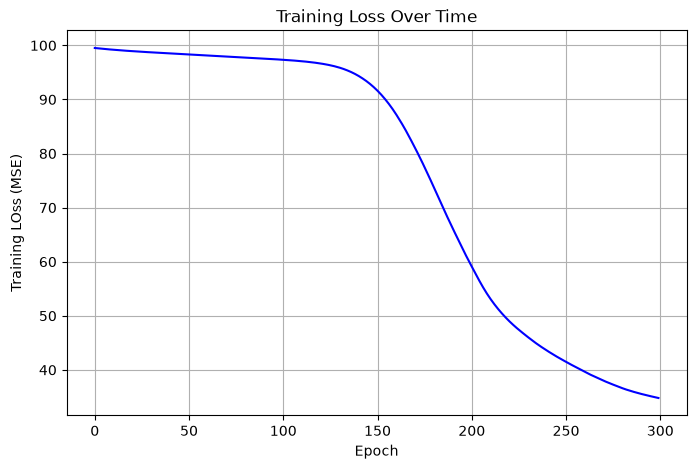

In [26]:
import matplotlib.pyplot as plt

# plot hte training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), train_losses, linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Training LOss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

In [27]:
# Evaluate model performance

with torch.no_grad():
    # predict on train set
    train_preds = model(X_train)
    train_loss = loss_fn(train_preds, y_train)

    # Predict on test set
    test_preds = model(X_test)
    test_loss = loss_fn(test_preds, y_test)


print(f"Final Training Loss (MSE): {train_loss.item():.4f} MPa")
print(f"Final Testing Loss (MSE): {test_loss.item():.4f} MPa")

Final Training Loss (MSE): 34.7244 MPa
Final Testing Loss (MSE): 40.5397 MPa


In [28]:
# For a more interpretable values, we take the square root of MSE:
# Calculate the RMSE
train_rmse = torch.sqrt(train_loss)
test_rmse = torch.sqrt(test_loss)

print(f"Trainng RMSE: {train_rmse.item():.2f} MPa")
print(f"Testing RMSE: {test_rmse.item():.2f} MPa")

Trainng RMSE: 5.89 MPa
Testing RMSE: 6.37 MPa


Essentially, the gap behind the training and testing RMSE is small. The model is not overfitting